In [ ]:
from sklearn.model_selection import cross_val_score, KFold, cross_validate, RepeatedKFold
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold, RFECV, RFE
from sklearn.linear_model import HuberRegressor


from ml_enhance import plot_scaled_linreg_result, CorrelationFilter


import matplotlib.pyplot as plt
from sklearn import pipeline
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
import json

In [ ]:
def make_pipeline(model, step_name):
    return pipeline.Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("remove_corr", CorrelationFilter(threshold=0.95)),
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", StandardScaler()),
        (step_name, model)
    ])

In [ ]:
pl_linear = make_pipeline(HuberRegressor(), "predict")

In [ ]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_even_more_qm.csv")

In [ ]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [ ]:
# drop any features

In [ ]:
def get_coef(estimator) -> np.ndarray:
    return estimator.named_steps['predict'].coef_

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rfe = RFECV(pl_linear, cv=kf, scoring="r2", n_jobs=4, importance_getter=get_coef)
rfe.fit(X, y)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,Pipeline(step...egression())])
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'r2'
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",4
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",<function get...0018A1F48A980>
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,threshold,0.95
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'


In [ ]:
# TO BE ADDED

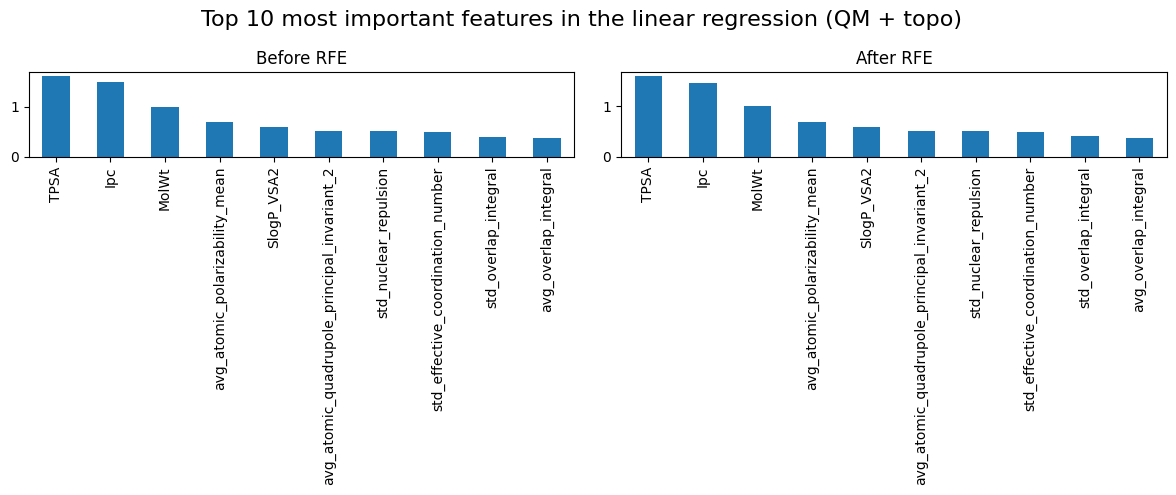

In [ ]:
pre_rfe_importance = pd.Series(
    best_pre_rfe_pl.named_steps["predict"].coef_,
    index=best_pre_rfe_pl[:-1].get_feature_names_out()
    )

post_rfe_importance = pd.Series(
    best_post_rfe_pl.named_steps["predict"].coef_,
    index=best_post_rfe_pl[:-1].get_feature_names_out()
    )

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

pre_rfe_importance.abs().sort_values(ascending=False)[:10].plot.bar(ax=ax[0])
ax[0].set_title("Before RFE")

post_rfe_importance.abs().sort_values(ascending=False)[:10].plot.bar(ax=ax[1])
ax[1].set_title("After RFE")

plt.suptitle("Top 10 most important features in the linear regression (QM + topo)", fontsize=16)
plt.tight_layout()
plt.show()